In [1]:
# Cell 1: Imports, Device & Directory Configurations
import os
import random
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from torchvision.models import swin_v2_t, vit_b_16

from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, f1_score,
    precision_score, recall_score, confusion_matrix, classification_report
)

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", DEVICE)

# Dataset Root Paths
DATASET_FOLDER = os.path.join("archive", "nih_imagefolder")
DATA_ROOT = os.environ.get("PNEUMONIA_DATA_ROOT", os.path.join(os.getcwd(), DATASET_FOLDER))

# Saved Checkpoint Paths for all 5 Models
RESNET_PATH = "./updated1_output/best_s2_mixup.pth"
DENSENET_PATH = "./e2_output/best_s2_mixup.pth"
EFFNET_PATH = "./ef_output/best_s2_mixup.pth"
SWIN_PATH = "./swin_output/best_s2_mixup.pth"
VIT_PATH = "./vit_output/best_s2_mixup.pth"

OUTPUT_DIR = "./ensemble_models/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH = 16
NUM_WORKERS = 4
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("Environment and Seeds Configured.")

Using Device: cpu
Environment and Seeds Configured.


In [2]:
# Cell 2: Data Loading & Preprocessing
# Standard resolution 256x256 is kept for Swin Transformer compatibility.
# For 224x224 models (ResNet, DenseNet, EfficientNet, ViT), dynamic bilinear interpolation is applied.
IMG_SIZE_SWIN = 256

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_SWIN, IMG_SIZE_SWIN)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_dir  = os.path.join(DATA_ROOT, "val")
test_dir = os.path.join(DATA_ROOT, "test")

missing_splits = [split for split in ("val", "test") if not os.path.isdir(os.path.join(DATA_ROOT, split))]
if missing_splits:
    raise FileNotFoundError(
        f"Prepared NIH dataset not found at {DATA_ROOT}. Run prepare_nih_xray14.py first. "
        f"Missing: {', '.join(missing_splits)}."
    )

val_ds  = datasets.ImageFolder(val_dir, transform=val_transform)
test_ds = datasets.ImageFolder(test_dir, transform=val_transform)

# DataLoaders: Validation set for candidate evaluation/tuning; Test set strictly for final one-time evaluation
val_loader  = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Class mapping:", val_ds.class_to_idx)
# Index 0: NORMAL, Index 1: PNEUMONIA
print(f"Validation set size (used for weight search & selection): {len(val_ds)}")
print(f"Test set size (strictly held out for final reporting): {len(test_ds)}")


Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}
Validation set size (used for weight search & selection): 10322
Test set size (strictly held out for final reporting): 10416


In [8]:
# Cell 3 — Load available base models

from pathlib import Path

PROJECT_ROOT = Path.cwd()

RESNET_PATH = PROJECT_ROOT / "updated1_output" / "best_s1_resnet50_nomixup.pth"
DENSENET_PATH = PROJECT_ROOT / "e2_output" / "best_s1_nomixup.pth"
EFFNET_PATH = PROJECT_ROOT / "ef_output" / "best_s1_efficientnet_nomixup.pth"
SWIN_PATH = PROJECT_ROOT / "swin_output" / "best_s1_nomixup.pth"
VIT_PATH = PROJECT_ROOT / "vit_output" / "best_s1_nomixup.pth"

checkpoint_paths = {
    "ResNet": RESNET_PATH,
    "DenseNet": DENSENET_PATH,
    "EfficientNet": EFFNET_PATH,
    "ViT": VIT_PATH,
}

missing = {
    name: str(path)
    for name, path in checkpoint_paths.items()
    if not path.is_file()
}

if missing:
    raise FileNotFoundError(
        "Missing model checkpoints:\n"
        + "\n".join(f"- {name}: {path}" for name, path in missing.items())
        + "\nTrain those models first, then rerun this cell."
    )


def load_resnet():
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 1)
    model.load_state_dict(torch.load(RESNET_PATH, map_location=DEVICE))
    return model.eval().to(DEVICE)


def load_densenet():
    model = models.densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, 1)
    model.load_state_dict(torch.load(DENSENET_PATH, map_location=DEVICE))
    return model.eval().to(DEVICE)


def load_effnet():
    model = models.efficientnet_b3(weights=None)
    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        1
    )
    model.load_state_dict(torch.load(EFFNET_PATH, map_location=DEVICE))
    return model.eval().to(DEVICE)


def load_swin():
    model = swin_v2_t(weights=None)
    model.head = nn.Linear(model.head.in_features, 1)
    model.load_state_dict(torch.load(SWIN_PATH, map_location=DEVICE))
    return model.eval().to(DEVICE)


def load_vit():
    model = vit_b_16(weights=None)
    model.heads.head = nn.Linear(
        model.heads.head.in_features,
        1
    )
    model.load_state_dict(torch.load(VIT_PATH, map_location=DEVICE))
    return model.eval().to(DEVICE)


print("Loading all 5 models...")

models_dict = {
    "ResNet": load_resnet(),
    "DenseNet": load_densenet(),
    "EfficientNet": load_effnet(),
    "ViT": load_vit(),
}

for model_name, model in models_dict.items():
    for parameter in model.parameters():
        parameter.requires_grad = False
    print(f"Loaded and frozen: {model_name}")

MODEL_NAMES = list(models_dict.keys())
print("All 5 base models successfully loaded.")

Loading all 5 models...
Loaded and frozen: ResNet
Loaded and frozen: DenseNet
Loaded and frozen: EfficientNet
Loaded and frozen: ViT
All 5 base models successfully loaded.


In [11]:
# Cell 4 — Prediction Extraction for Available Models

def get_model_predictions(models_dict, loader, device):
    """
    Extract sigmoid probabilities for all loaded models.
    Current models: ResNet, DenseNet, EfficientNet, and ViT.
    """

    all_probs = {
        name: [] for name in MODEL_NAMES
    }
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(
            loader,
            desc="Extracting Model Predictions"
        ):
            imgs = imgs.to(device, non_blocking=True)

            # All currently loaded models use 224x224 input.
            imgs_224 = F.interpolate(
                imgs,
                size=(224, 224),
                mode="bilinear",
                align_corners=False
            )

            for model_name in MODEL_NAMES:
                logits = models_dict[model_name](imgs_224)
                probabilities = torch.sigmoid(logits)

                all_probs[model_name].extend(
                    probabilities.cpu().numpy().reshape(-1)
                )

            all_labels.extend(
                labels.cpu().numpy().reshape(-1)
            )

    prob_matrix = np.column_stack(
        [all_probs[name] for name in MODEL_NAMES]
    )

    labels_arr = np.asarray(all_labels)

    if not np.all(
        (prob_matrix >= 0.0) &
        (prob_matrix <= 1.0)
    ):
        raise ValueError(
            "Model probabilities must be between 0 and 1."
        )

    return prob_matrix, labels_arr


print("Extracting predictions on validation set...")
val_probs, val_labels = get_model_predictions(
    models_dict,
    val_loader,
    DEVICE
)

print("Extracting predictions on test set...")
test_probs, test_labels = get_model_predictions(
    models_dict,
    test_loader,
    DEVICE
)

print("Loaded models:", MODEL_NAMES)
print(f"Validation probability matrix shape: {val_probs.shape}")
print(f"Test probability matrix shape: {test_probs.shape}")

Extracting predictions on validation set...


Extracting Model Predictions: 100%|██████████| 646/646 [46:32<00:00,  4.32s/it]


Extracting predictions on test set...


Extracting Model Predictions: 100%|██████████| 651/651 [44:47<00:00,  4.13s/it]

Loaded models: ['ResNet', 'DenseNet', 'EfficientNet', 'ViT']
Validation probability matrix shape: (10322, 4)
Test probability matrix shape: (10416, 4)


In [12]:
# Cell 5: Systematic Candidate Weight Generation
def generate_candidate_weights(n_models=5, step=0.05):
    """
    Systematically generates candidate weight combinations where:
      - w_i >= 0 for each model
      - sum(w) == 1.0 (verified within 1e-6)
    Includes:
      - Equal weighting baseline [0.2, 0.2, 0.2, 0.2, 0.2]
      - Single-model dominant combinations (e.g. 0.6 on ViT or Swin)
      - CNN-focused, Transformer-focused, and mixed hybrid candidate combinations
      - Grid simplex combinations with discretization step.
    """
    candidates = []
    
    # Baseline equal weighting
    candidates.append([1.0 / n_models] * n_models)

    # Individual model dominance combinations (primary model at 0.50 or 0.60, rest shared)
    for i in range(n_models):
        for lead_w in [0.40, 0.50, 0.60]:
            rem = round(1.0 - lead_w, 4)
            w = [round(rem / (n_models - 1), 4)] * n_models
            w[i] = lead_w
            # Adjust minor floating rounding
            diff = 1.0 - sum(w)
            w[0] += diff
            candidates.append([round(x, 4) for x in w])

    # CNN-dominant vs Transformer-dominant combinations
    # ResNet(0), DenseNet(1), EffNet(2), Swin(3), ViT(4)
    candidates.append([0.25, 0.25, 0.25, 0.125, 0.125]) # CNN heavy
    candidates.append([0.10, 0.10, 0.10, 0.35, 0.35])   # Transformer heavy
    candidates.append([0.15, 0.15, 0.20, 0.25, 0.25])   # Balanced hybrid
    candidates.append([0.10, 0.20, 0.30, 0.20, 0.20])   # Dense/EffNet priority
    candidates.append([0.15, 0.15, 0.30, 0.20, 0.20])   # EffNet priority
    candidates.append([0.10, 0.15, 0.25, 0.25, 0.25])   # Multi-lead

    # Controlled simplex grid generation
    # Multiples of 0.10 to maintain clean search space without combinatorial explosion
    steps = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
    for comb in itertools.product(steps, repeat=n_models):
        if abs(sum(comb) - 1.0) < 1e-6:
            candidates.append([round(x, 4) for x in comb])

    # Remove duplicates
    unique_candidates = []
    seen = set()
    for w in candidates:
        w_tuple = tuple(np.round(w, 4))
        if w_tuple not in seen:
            seen.add(w_tuple)
            unique_candidates.append(np.array(w_tuple, dtype=np.float64))

    # Assert validity
    for w in unique_candidates:
        assert np.all(w >= -1e-6), f"Negative weight detected: {w}"
        assert abs(np.sum(w) - 1.0) < 1e-5, f"Weights do not sum to 1: {w}, sum={np.sum(w)}"

    return np.array(unique_candidates)

candidate_weights = generate_candidate_weights(n_models=5)
print(f"Generated {len(candidate_weights)} valid candidate weight combinations.")
print("Sample Candidate 1 (Equal):", candidate_weights[0])
print("Sample Candidate 2:", candidate_weights[1])
print("Sample Candidate 3:", candidate_weights[2])


Generated 671 valid candidate weight combinations.
Sample Candidate 1 (Equal): [0.2 0.2 0.2 0.2 0.2]
Sample Candidate 2: [0.4  0.15 0.15 0.15 0.15]
Sample Candidate 3: [0.5   0.125 0.125 0.125 0.125]


In [17]:
# Cell 6 — Validation Weight Evaluation for Available Models

n_models = len(MODEL_NAMES)

if val_probs.shape[1] != n_models:
    raise ValueError(
        f"val_probs has {val_probs.shape[1]} columns, "
        f"but {n_models} models are loaded."
    )

# Generate weights with exactly one value per loaded model.
candidate_weights = []

# Equal weights.
candidate_weights.append(
    np.full(n_models, 1.0 / n_models)
)

# Give one model more importance.
for model_index in range(n_models):
    for lead_weight in (0.4, 0.5, 0.6):
        weights = np.full(
            n_models,
            (1.0 - lead_weight) / (n_models - 1)
        )
        weights[model_index] = lead_weight
        candidate_weights.append(weights)

# Grid-search weights in increments of 0.1.
for values in itertools.product(
    np.arange(0.0, 1.01, 0.1),
    repeat=n_models
):
    if np.isclose(sum(values), 1.0):
        candidate_weights.append(np.asarray(values))

# Remove duplicate combinations.
candidate_weights = np.unique(
    np.round(np.asarray(candidate_weights), 4),
    axis=0
)

print("Loaded models:", MODEL_NAMES)
print("Candidate weights shape:", candidate_weights.shape)


def evaluate_predictions(y_true, y_probs):
    auc = roc_auc_score(y_true, y_probs)

    best_metrics = {
        "AUC": auc,
        "Accuracy": 0.0,
        "Precision": 0.0,
        "Recall": 0.0,
        "F1": 0.0,
        "Threshold": 0.5
    }

    for threshold in np.linspace(0.1, 0.9, 81):
        predictions = (y_probs >= threshold).astype(int)

        current_f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )

        if current_f1 > best_metrics["F1"]:
            best_metrics.update({
                "Accuracy": accuracy_score(
                    y_true,
                    predictions
                ),
                "Precision": precision_score(
                    y_true,
                    predictions,
                    zero_division=0
                ),
                "Recall": recall_score(
                    y_true,
                    predictions,
                    zero_division=0
                ),
                "F1": current_f1,
                "Threshold": threshold
            })

    return best_metrics


results = []

for index, weights in enumerate(candidate_weights):
    combined_prob = np.dot(val_probs, weights)
    metrics = evaluate_predictions(
        val_labels,
        combined_prob
    )

    result = {
        "Combination": index + 1,
        **{
            model_name: weight
            for model_name, weight in zip(
                MODEL_NAMES,
                weights
            )
        },
        **metrics
    }

    results.append(result)

val_weight_results = pd.DataFrame(results)

val_weight_results = val_weight_results.sort_values(
    by=["F1", "AUC", "Accuracy"],
    ascending=False
).reset_index(drop=True)

print("\nTop 10 candidate combinations:")
print(
    val_weight_results
    .head(10)
    .to_string(index=False)
)

best_val_row = val_weight_results.iloc[0]

best_fixed_weights = np.asarray([
    best_val_row[model_name]
    for model_name in MODEL_NAMES
])

if not np.isclose(
    best_fixed_weights.sum(),
    1.0
):
    raise ValueError(
        "Best weights do not sum to 1."
    )

if np.any(best_fixed_weights < 0):
    raise ValueError(
        "Best weights cannot be negative."
    )

print("\n" + "=" * 60)
print(
    f"BEST FIXED WEIGHTS "
    f"(Combination #{int(best_val_row['Combination'])})"
)

for model_name, weight in zip(
    MODEL_NAMES,
    best_fixed_weights
):
    print(f"{model_name}: {weight:.4f}")

print(
    f"Val F1: {best_val_row['F1']:.4f} | "
    f"Val AUC: {best_val_row['AUC']:.4f} | "
    f"Val Accuracy: "
    f"{best_val_row['Accuracy'] * 100:.2f}%"
)

print("=" * 60)

Loaded models: ['ResNet', 'DenseNet', 'EfficientNet', 'ViT']
Candidate weights shape: (295, 4)

Top 10 candidate combinations:
 Combination  ResNet  DenseNet  EfficientNet  ViT      AUC  Accuracy  Precision   Recall       F1  Threshold
           6     0.0       0.0           0.5  0.5 0.665435  0.965414   0.090129 0.126506 0.105263       0.55
           7     0.0       0.0           0.6  0.4 0.661095  0.966576   0.091324 0.120482 0.103896       0.55
         132     0.2       0.0           0.4  0.4 0.667921  0.961442   0.082734 0.138554 0.103604       0.54
          71     0.1       0.0           0.4  0.5 0.667487  0.958826   0.078176 0.144578 0.101480       0.54
          81     0.1       0.1           0.4  0.4 0.670426  0.962217   0.082090 0.132530 0.101382       0.55
          16     0.0       0.1           0.4  0.5 0.669634  0.967351   0.090909 0.114458 0.101333       0.56
           5     0.0       0.0           0.4  0.6 0.666057  0.974133   0.114504 0.090361 0.101010       0.57
 

In [18]:
# Cell 7 — Input-Dependent Dynamic Weight Selection

candidate_val_f1 = dict(
    zip(
        val_weight_results["Combination"],
        val_weight_results["F1"]
    )
)


def select_dynamic_weights_for_sample(
    model_probs,
    candidates,
    candidate_f1_scores
):
    confidences = np.abs(model_probs - 0.5) * 2.0

    best_score = -np.inf
    best_weights = None

    for index, weights in enumerate(candidates):
        confidence_alignment = np.dot(
            weights,
            confidences
        )

        validation_f1 = candidate_f1_scores.get(
            index + 1,
            0.5
        )

        score = confidence_alignment * (
            validation_f1 ** 2
        )

        if score > best_score:
            best_score = score
            best_weights = weights

    if best_weights is None:
        raise ValueError("No dynamic weight vector was selected.")

    if not np.isclose(best_weights.sum(), 1.0):
        raise ValueError(
            "Selected weights do not sum to 1."
        )

    if np.any(best_weights < 0):
        raise ValueError(
            "Selected weights contain negative values."
        )

    return best_weights


def dynamic_ensemble_predict(
    probs_matrix,
    candidates,
    candidate_f1_scores
):
    if probs_matrix.shape[1] != len(MODEL_NAMES):
        raise ValueError(
            f"Probability matrix has {probs_matrix.shape[1]} columns, "
            f"but {len(MODEL_NAMES)} models are loaded."
        )

    sample_count = probs_matrix.shape[0]
    model_count = probs_matrix.shape[1]

    final_probs = np.zeros(sample_count)
    selected_weights = np.zeros(
        (sample_count, model_count)
    )

    for sample_index in range(sample_count):
        weights = select_dynamic_weights_for_sample(
            probs_matrix[sample_index],
            candidates,
            candidate_f1_scores
        )

        selected_weights[sample_index] = weights
        final_probs[sample_index] = np.dot(
            probs_matrix[sample_index],
            weights
        )

    return final_probs, selected_weights


print("Running dynamic selection on validation set...")

val_dyn_probs, val_dyn_weights = dynamic_ensemble_predict(
    val_probs,
    candidate_weights,
    candidate_val_f1
)

val_dyn_metrics = evaluate_predictions(
    val_labels,
    val_dyn_probs
)

print("Running dynamic selection on test set...")

test_dyn_probs, test_dyn_weights = dynamic_ensemble_predict(
    test_probs,
    candidate_weights,
    candidate_val_f1
)

weight_std_per_model = np.std(
    test_dyn_weights,
    axis=0
)

print("\nWeight variation across test samples:")

for model_name, weight_std in zip(
    MODEL_NAMES,
    weight_std_per_model
):
    print(
        f"{model_name:15s} "
        f"weight std dev = {weight_std:.4f}"
    )

if not np.any(weight_std_per_model > 1e-4):
    print(
        "Warning: selected weights did not vary "
        "significantly across samples."
    )
else:
    print(
        "Verified: weights vary across test samples."
    )

Running dynamic selection on validation set...
Running dynamic selection on test set...

Weight variation across test samples:
ResNet          weight std dev = 0.0581
DenseNet        weight std dev = 0.2007
EfficientNet    weight std dev = 0.1715
ViT             weight std dev = 0.2075
Verified: weights vary across test samples.


In [19]:
# Cell 8 — Final Test Set Comparison

comparison_records = []


def add_result(name, metrics):
    comparison_records.append({
        "Model / Ensemble Configuration": name,
        "Accuracy (%)": f"{metrics['Accuracy'] * 100:.2f}%",
        "Precision": f"{metrics['Precision']:.4f}",
        "Recall": f"{metrics['Recall']:.4f}",
        "F1-Score": f"{metrics['F1']:.4f}",
        "ROC-AUC": f"{metrics['AUC']:.4f}",
        "Optimal Thr": f"{metrics['Threshold']:.3f}"
    })


# A. Individual models
for index, model_name in enumerate(MODEL_NAMES):
    metrics = evaluate_predictions(
        test_labels,
        test_probs[:, index]
    )
    add_result(f"Individual: {model_name}", metrics)


# B. Equal-weight ensemble
equal_weights = np.full(
    len(MODEL_NAMES),
    1.0 / len(MODEL_NAMES)
)

test_equal_probs = np.dot(
    test_probs,
    equal_weights
)

metrics_equal = evaluate_predictions(
    test_labels,
    test_equal_probs
)

add_result(
    "Static Ensemble (Equal Weights)",
    metrics_equal
)


# C. Best fixed validation-weight ensemble
if len(best_fixed_weights) != len(MODEL_NAMES):
    raise ValueError(
        "Best fixed weights do not match the loaded models."
    )

test_fixed_probs = np.dot(
    test_probs,
    best_fixed_weights
)

metrics_fixed = evaluate_predictions(
    test_labels,
    test_fixed_probs
)

add_result(
    "Best Fixed Validation-Weight Ensemble",
    metrics_fixed
)


# D. Dynamic input-dependent ensemble
# Use the validation-selected threshold to avoid test leakage.
dynamic_threshold = val_dyn_metrics["Threshold"]

test_dynamic_predictions = (
    test_dyn_probs >= dynamic_threshold
).astype(int)

dynamic_metrics = {
    "Accuracy": accuracy_score(
        test_labels,
        test_dynamic_predictions
    ),
    "Precision": precision_score(
        test_labels,
        test_dynamic_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        test_labels,
        test_dynamic_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        test_labels,
        test_dynamic_predictions,
        zero_division=0
    ),
    "AUC": roc_auc_score(
        test_labels,
        test_dyn_probs
    ),
    "Threshold": dynamic_threshold
}

add_result(
    "Dynamic Ensemble (Input-Dependent Weights)",
    dynamic_metrics
)


df_comparison = pd.DataFrame(comparison_records)

print("\n" + "=" * 80)
print("FINAL TEST SET PERFORMANCE COMPARISON")
print("=" * 80)
print(df_comparison.to_markdown(index=False))
print("=" * 80)

print("\nLoaded models:", MODEL_NAMES)
print("\nClassification Report for Dynamic Ensemble:")
print(
    classification_report(
        test_labels,
        test_dynamic_predictions,
        target_names=["NORMAL", "PNEUMONIA"],
        digits=4,
        zero_division=0
    )
)


FINAL TEST SET PERFORMANCE COMPARISON
| Model / Ensemble Configuration             | Accuracy (%)   |   Precision |   Recall |   F1-Score |   ROC-AUC |   Optimal Thr |
|:-------------------------------------------|:---------------|------------:|---------:|-----------:|----------:|--------------:|
| Individual: ResNet                         | 60.19%         |      0.066  |   0.4919 |     0.1163 |    0.5647 |          0.51 |
| Individual: DenseNet                       | 48.35%         |      0.0618 |   0.6126 |     0.1122 |    0.5576 |          0.57 |
| Individual: EfficientNet                   | 32.05%         |      0.0567 |   0.7514 |     0.1054 |    0.538  |          0.51 |
| Individual: ViT                            | 73.69%         |      0.0863 |   0.4108 |     0.1427 |    0.6166 |          0.48 |
| Static Ensemble (Equal Weights)            | 72.28%         |      0.0827 |   0.4162 |     0.138  |    0.6146 |          0.53 |
| Best Fixed Validation-Weight Ensemble      | 75.3

In [20]:
# Cell 9 — Export Per-Sample Dynamic Weights

sample_data = {
    "sample_index": np.arange(len(test_labels)),
    "actual_label": test_labels,
    "label_name": [
        "PNEUMONIA" if label == 1 else "NORMAL"
        for label in test_labels
    ]
}

# Add probabilities dynamically for loaded models.
for index, model_name in enumerate(MODEL_NAMES):
    column_name = model_name.lower() + "_probability"
    sample_data[column_name] = np.round(
        test_probs[:, index],
        4
    )

# Add selected dynamic weights dynamically.
for index, model_name in enumerate(MODEL_NAMES):
    column_name = model_name.lower() + "_weight"
    sample_data[column_name] = np.round(
        test_dyn_weights[:, index],
        4
    )

sample_data["weight_sum"] = np.round(
    np.sum(test_dyn_weights, axis=1),
    4
)

sample_data["final_probability"] = np.round(
    test_dyn_probs,
    4
)

sample_data["final_prediction"] = (
    test_dyn_probs >= val_dyn_metrics["Threshold"]
).astype(int)

df_samples = pd.DataFrame(sample_data)

os.makedirs(OUTPUT_DIR, exist_ok=True)

csv_export_path = os.path.join(
    OUTPUT_DIR,
    "dynamic_ensemble_sample_weights.csv"
)

df_samples.to_csv(
    csv_export_path,
    index=False
)

print(
    f"Saved {len(df_samples)} samples to:\n"
    f"{csv_export_path}"
)

display_columns = (
    ["actual_label"]
    + [
        model_name.lower() + "_weight"
        for model_name in MODEL_NAMES
    ]
    + ["weight_sum", "final_probability"]
)

print("\nSample dynamic weights:")
print(
    df_samples[display_columns]
    .head(10)
    .to_string(index=False)
)

Saved 10416 samples to:
./ensemble_models/dynamic_ensemble_sample_weights.csv

Sample dynamic weights:
 actual_label  resnet_weight  densenet_weight  efficientnet_weight  vit_weight  weight_sum  final_probability
            0            0.0              0.1                  0.0         0.9         1.0             0.4097
            0            0.1              0.1                  0.0         0.8         1.0             0.6092
            0            0.0              0.1                  0.0         0.9         1.0             0.5494
            0            0.5              0.0                  0.0         0.5         1.0             0.5207
            0            0.0              0.1                  0.5         0.4         1.0             0.5250
            0            0.0              0.0                  0.6         0.4         1.0             0.5170
            0            0.0              0.5                  0.0         0.5         1.0             0.5231
            0    

In [21]:
# Cell 10 — Dynamic Post-Hoc Calibrator

class DynamicCalibrator(nn.Module):
    """
    Calibrates dynamic ensemble logits using prediction variance.
    Works with any number of loaded models.
    """

    def __init__(self):
        super().__init__()

        self.temp_net = nn.Sequential(
            nn.Linear(1, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Softplus()
        )

        for module in self.temp_net.modules():
            if isinstance(module, nn.Linear):
                nn.init.uniform_(
                    module.weight,
                    -0.1,
                    0.1
                )
                nn.init.constant_(
                    module.bias,
                    0.5
                )

    def forward(self, ensemble_logits, probability_variance):
        temperature = self.temp_net(
            probability_variance
        ) + 1e-6

        calibrated_logits = ensemble_logits / temperature

        return calibrated_logits, temperature


eps = 1e-6


def probabilities_to_logits(probabilities):
    clipped = np.clip(
        probabilities,
        eps,
        1.0 - eps
    )

    return np.log(
        clipped / (1.0 - clipped)
    )


# Variance across currently loaded models.
val_prob_variance = torch.tensor(
    np.var(
        val_probs,
        axis=1,
        keepdims=True
    ),
    dtype=torch.float32,
    device=DEVICE
)

test_prob_variance = torch.tensor(
    np.var(
        test_probs,
        axis=1,
        keepdims=True
    ),
    dtype=torch.float32,
    device=DEVICE
)

val_dynamic_logits = torch.tensor(
    probabilities_to_logits(val_dyn_probs),
    dtype=torch.float32,
    device=DEVICE
).unsqueeze(1)

test_dynamic_logits = torch.tensor(
    probabilities_to_logits(test_dyn_probs),
    dtype=torch.float32,
    device=DEVICE
).unsqueeze(1)

val_labels_tensor = torch.tensor(
    val_labels,
    dtype=torch.float32,
    device=DEVICE
).unsqueeze(1)


calibrator = DynamicCalibrator().to(DEVICE)

optimizer_calibrator = optim.Adam(
    calibrator.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

calibration_loss = nn.BCEWithLogitsLoss()

print("Training dynamic calibrator on validation set...")

calibrator.train()

for epoch in range(15):
    optimizer_calibrator.zero_grad()

    calibrated_logits, _ = calibrator(
        val_dynamic_logits,
        val_prob_variance
    )

    loss = calibration_loss(
        calibrated_logits,
        val_labels_tensor
    )

    loss.backward()
    optimizer_calibrator.step()

    if (epoch + 1) % 5 == 0:
        print(
            f"Calibrator Epoch {epoch + 1}/15 | "
            f"Loss: {loss.item():.4f}"
        )


calibrator.eval()

with torch.no_grad():
    test_calibrated_logits, test_temperatures = calibrator(
        test_dynamic_logits,
        test_prob_variance
    )

    test_calibrated_probs = torch.sigmoid(
        test_calibrated_logits
    ).cpu().numpy().reshape(-1)


calibration_metrics = evaluate_predictions(
    test_labels,
    test_calibrated_probs
)

print(
    "\nCalibrated Dynamic Ensemble | "
    f"Test AUC: {calibration_metrics['AUC']:.4f} | "
    f"Test F1: {calibration_metrics['F1']:.4f}"
)


os.makedirs(OUTPUT_DIR, exist_ok=True)

calibrator_path = os.path.join(
    OUTPUT_DIR,
    "best_dynamic_calibrator.pth"
)

torch.save(
    calibrator.state_dict(),
    calibrator_path
)

print(
    f"Saved calibrator checkpoint to: {calibrator_path}"
)

Training dynamic calibrator on validation set...
Calibrator Epoch 5/15 | Loss: 0.5191
Calibrator Epoch 10/15 | Loss: 0.5168
Calibrator Epoch 15/15 | Loss: 0.5144

Calibrated Dynamic Ensemble | Test AUC: 0.6071 | Test F1: 0.1334
Saved calibrator checkpoint to: ./ensemble_models/best_dynamic_calibrator.pth


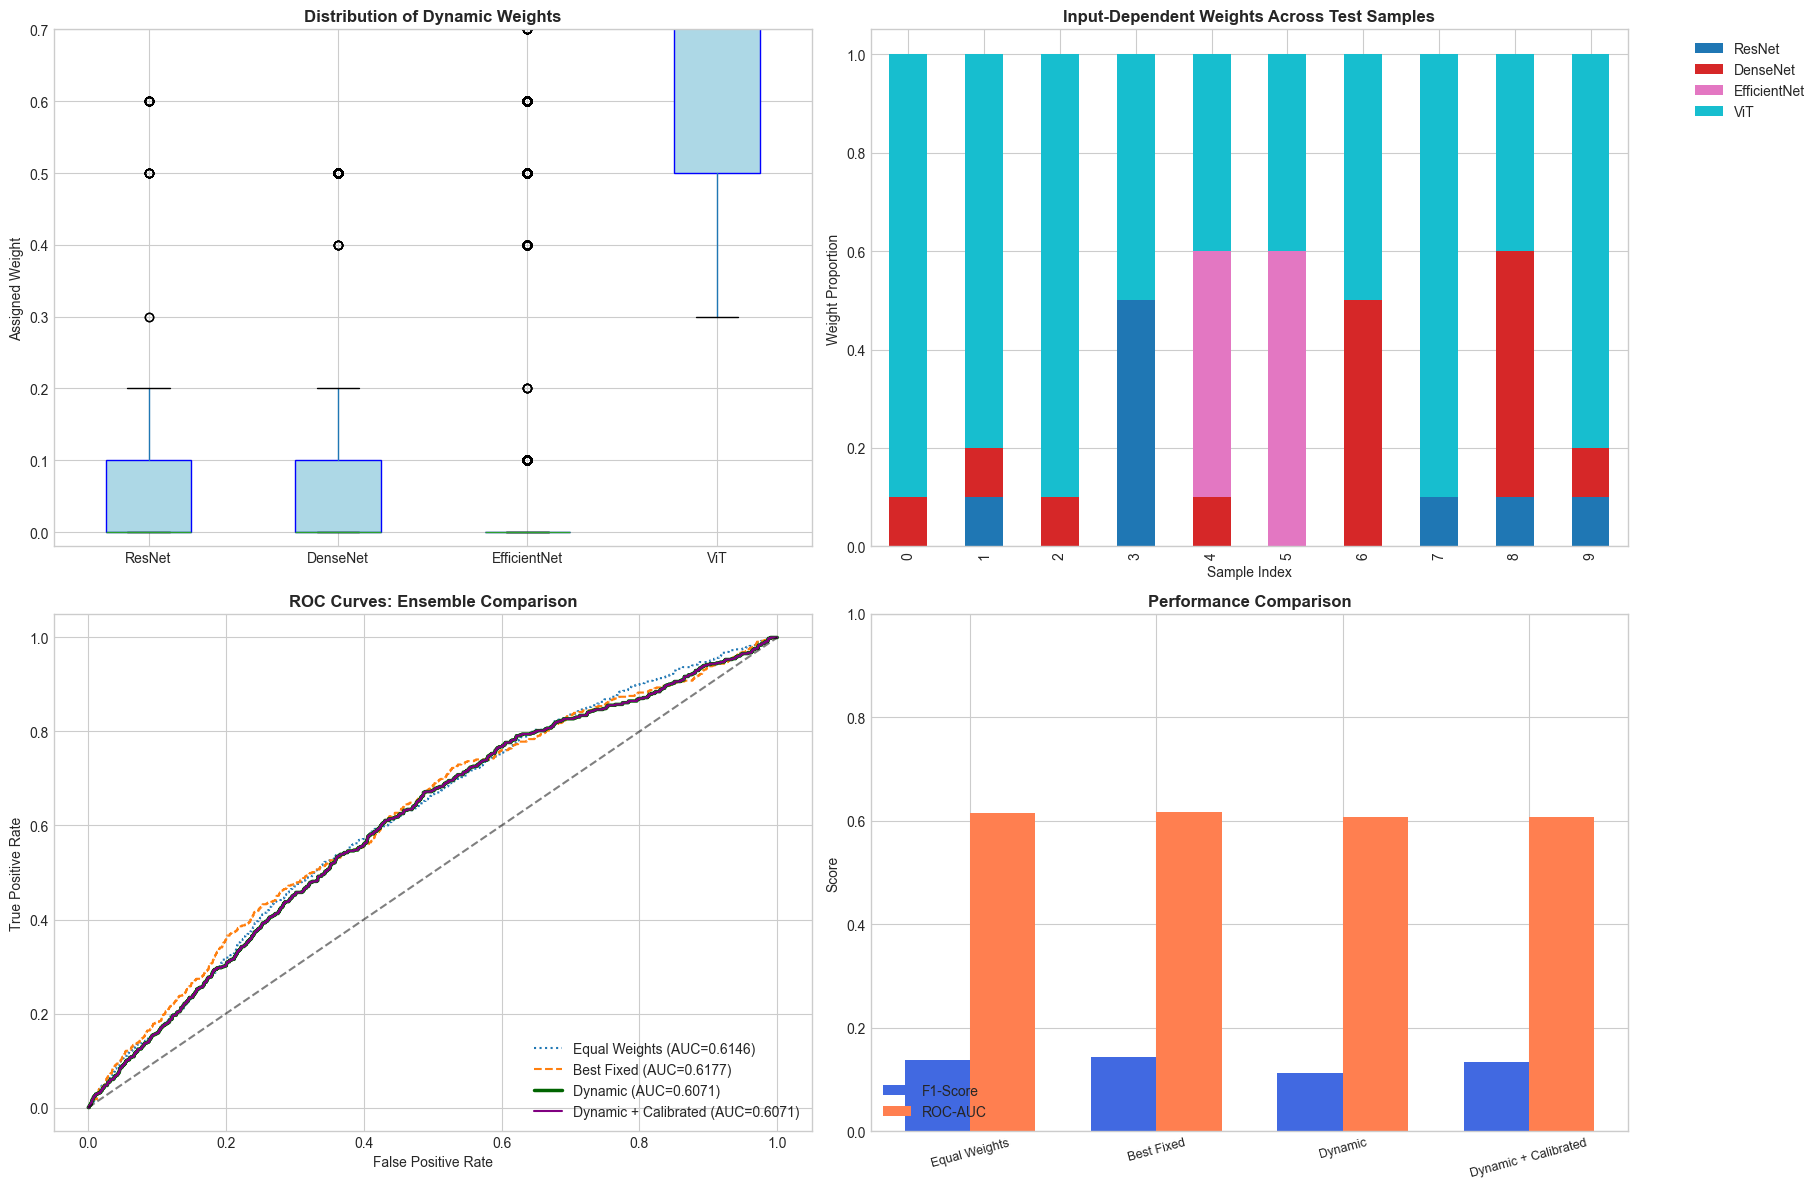

Visualizations saved to: ./ensemble_models/ensemble_comparison_plots.png


In [22]:
# Cell 11 — Scientific Visualizations

plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)

fig = plt.figure(figsize=(18, 12))

# 1. Dynamic weight distributions
ax1 = plt.subplot(2, 2, 1)

df_weights = pd.DataFrame(
    test_dyn_weights,
    columns=MODEL_NAMES
)

df_weights.boxplot(
    ax=ax1,
    patch_artist=True,
    boxprops={
        "facecolor": "lightblue",
        "color": "blue"
    }
)

ax1.set_title(
    "Distribution of Dynamic Weights",
    fontsize=12,
    fontweight="bold"
)
ax1.set_ylabel("Assigned Weight")
ax1.set_ylim(-0.02, 0.7)

# 2. Weights for first 10 test samples
ax2 = plt.subplot(2, 2, 2)

df_weights.head(10).plot(
    kind="bar",
    stacked=True,
    ax=ax2,
    colormap="tab10"
)

ax2.set_title(
    "Input-Dependent Weights Across Test Samples",
    fontsize=12,
    fontweight="bold"
)
ax2.set_xlabel("Sample Index")
ax2.set_ylabel("Weight Proportion")
ax2.set_ylim(0, 1.05)
ax2.legend(
    loc="upper right",
    bbox_to_anchor=(1.25, 1.0)
)

# 3. ROC curves
ax3 = plt.subplot(2, 2, 3)

fpr_equal, tpr_equal, _ = roc_curve(
    test_labels,
    test_equal_probs
)

fpr_fixed, tpr_fixed, _ = roc_curve(
    test_labels,
    test_fixed_probs
)

fpr_dynamic, tpr_dynamic, _ = roc_curve(
    test_labels,
    test_dyn_probs
)

fpr_calibrated, tpr_calibrated, _ = roc_curve(
    test_labels,
    test_calibrated_probs
)

ax3.plot(
    fpr_equal,
    tpr_equal,
    label=f"Equal Weights (AUC={metrics_equal['AUC']:.4f})",
    linestyle=":"
)

ax3.plot(
    fpr_fixed,
    tpr_fixed,
    label=f"Best Fixed (AUC={metrics_fixed['AUC']:.4f})",
    linestyle="--"
)

ax3.plot(
    fpr_dynamic,
    tpr_dynamic,
    label=f"Dynamic (AUC={dynamic_metrics['AUC']:.4f})",
    linewidth=2.5,
    color="darkgreen"
)

ax3.plot(
    fpr_calibrated,
    tpr_calibrated,
    label=(
        f"Dynamic + Calibrated "
        f"(AUC={calibration_metrics['AUC']:.4f})"
    ),
    linewidth=1.5,
    color="purple"
)

ax3.plot(
    [0, 1],
    [0, 1],
    "k--",
    alpha=0.5
)

ax3.set_title(
    "ROC Curves: Ensemble Comparison",
    fontsize=12,
    fontweight="bold"
)
ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.legend(loc="lower right")

# 4. Metric comparison
ax4 = plt.subplot(2, 2, 4)

configurations = [
    "Equal Weights",
    "Best Fixed",
    "Dynamic",
    "Dynamic + Calibrated"
]

f1_scores = [
    metrics_equal["F1"],
    metrics_fixed["F1"],
    dynamic_metrics["F1"],
    calibration_metrics["F1"]
]

auc_scores = [
    metrics_equal["AUC"],
    metrics_fixed["AUC"],
    dynamic_metrics["AUC"],
    calibration_metrics["AUC"]
]

x = np.arange(len(configurations))
width = 0.35

ax4.bar(
    x - width / 2,
    f1_scores,
    width,
    label="F1-Score",
    color="royalblue"
)

ax4.bar(
    x + width / 2,
    auc_scores,
    width,
    label="ROC-AUC",
    color="coral"
)

ax4.set_xticks(x)
ax4.set_xticklabels(
    configurations,
    rotation=15,
    fontsize=9
)
ax4.set_ylim(0.0, 1.0)
ax4.set_ylabel("Score")
ax4.set_title(
    "Performance Comparison",
    fontsize=12,
    fontweight="bold"
)
ax4.legend(loc="lower left")

plt.tight_layout()

os.makedirs(OUTPUT_DIR, exist_ok=True)

viz_path = os.path.join(
    OUTPUT_DIR,
    "ensemble_comparison_plots.png"
)

plt.savefig(
    viz_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Visualizations saved to: {viz_path}")